# 02 Baseline CNN Classification

This notebook builds the first classification model for the Advanced Computer Vision group project.

The goal is to train a custom convolutional neural network from scratch on the Oxford-IIIT Pet Dataset. This baseline CNN will provide a comparison point for later transfer learning models.

The project uses the full 37-class pet breed classification task. Although the dataset contains both cats and dogs, the prediction target is the breed label.

This notebook will:

1. Load the Oxford-IIIT Pet Dataset.
2. Create training, validation, and test datasets.
3. Resize and batch images for CNN training.
    4. Apply data augmentation to the training set.
5. Build a custom CNN baseline model.
6. Train the baseline model.
7. Evaluate performance.
8. Save the model, metrics, and figures.

## 1. Imports and Configuration

This section imports the libraries needed for TensorFlow/Keras model training, dataset preparation, evaluation, and plotting.

The baseline model is intentionally simple compared to pretrained architectures. Its purpose is to establish a reasonable starting point for comparison.

In [1]:
#
# Imports and Configuration
#

# Standard library imports
# random supports reproducible sampling.
# pathlib helps us manage project folders cleanly.
import random
from pathlib import Path

# Core data science imports
# numpy supports numerical operations.
# pandas supports tabular summaries.
# matplotlib supports training and evaluation plots.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TensorFlow imports
# TensorFlow and Keras are used to build and train the CNN.
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers

# Evaluation imports
# sklearn tools are used for classification reports and confusion matrices.
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility settings
# These seeds make random operations more repeatable.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Project constants
# These values will be used consistently throughout the modeling notebooks.
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 37
VALIDATION_FRACTION = 0.20

# Training constants
# We start with a modest epoch count for the baseline CNN.
# Early stopping will stop training if validation performance stops improving.
EPOCHS = 20
LEARNING_RATE = 0.001

# Print version information for reproducibility.
print("TensorFlow version:", tf.__version__)
print("TensorFlow Datasets version:", tfds.__version__)

TensorFlow version: 2.19.1
TensorFlow Datasets version: 4.9.9


## 2. Project Directory Setup

The notebook saves outputs into organized folders so that later notebooks, the final report, and the presentation can reuse them.

This notebook will save:

- baseline training curves,
- baseline classification report,
- baseline confusion matrix,
- baseline model file.

In [2]:
#
# Project Directory Setup
#

# Determine the project root.
# This assumes the notebook is either inside the notebooks folder
# or is being run from the project root.
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

# Define project output directories.
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
RESULTS_DIR = OUTPUT_DIR / "results"
MODEL_DIR = OUTPUT_DIR / "models"

# Create the directories if they do not already exist.
for directory in [DATA_DIR, OUTPUT_DIR, FIGURE_DIR, RESULTS_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Figure directory:", FIGURE_DIR)
print("Results directory:", RESULTS_DIR)
print("Model directory:", MODEL_DIR)

Project root: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project
Figure directory: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/figures
Results directory: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/results
Model directory: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/models


## 3. Load the Oxford-IIIT Pet Dataset

We load the same dataset used in Notebook 01. The dataset has already been downloaded and prepared, so TensorFlow Datasets should reuse the local cached copy.

For this baseline CNN, we use:

- the official training split for training and validation,
- the official test split for final testing,
    - the breed label as the target variable.

In [3]:
#
# Load the Oxford-IIIT Pet Dataset
#

# Load the official train and test splits.
# as_supervised=False keeps the full example dictionary.
# This allows us to access image, label, species, file name, and other fields if needed.
(ds_train_raw, ds_test_raw), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train", "test"],
    as_supervised=False,
    with_info=True,
    shuffle_files=False
)

# Store split sizes.
num_train_raw = ds_info.splits["train"].num_examples
num_test = ds_info.splits["test"].num_examples
num_total = num_train_raw + num_test

# Extract human-readable breed names.
breed_names = ds_info.features["label"].names

print("Dataset name:", ds_info.name)
print("Dataset version:", ds_info.version)
print("Raw training examples:", num_train_raw)
print("Test examples:", num_test)
print("Total examples:", num_total)
print("Number of breed classes:", len(breed_names))

Dataset name: oxford_iiit_pet
Dataset version: 4.0.0
Raw training examples: 3680
Test examples: 3669
Total examples: 7349
Number of breed classes: 37


## 4. Create Training and Validation Splits

The Oxford-IIIT Pet Dataset provides official train and test splits. For model development, we also create a validation split from the official training data.

The validation set is used during training to monitor generalization and support early stopping.

In [4]:
#
# Create Training and Validation Splits
#

# Calculate the number of validation examples.
num_validation = int(num_train_raw * VALIDATION_FRACTION)
num_train = num_train_raw - num_validation

# Shuffle the official training split before separating it into train and validation sets.
# This makes the validation split more representative.
ds_train_shuffled = ds_train_raw.shuffle(
    buffer_size=num_train_raw,
    seed=SEED,
    reshuffle_each_iteration=False
)

# Create the validation split from the beginning of the shuffled training data.
ds_val_raw = ds_train_shuffled.take(num_validation)

# Create the training split from the remaining shuffled training data.
ds_train_raw_final = ds_train_shuffled.skip(num_validation)

print("Training examples:", num_train)
print("Validation examples:", num_validation)
print("Test examples:", num_test)

Training examples: 2944
Validation examples: 736
Test examples: 3669


## 5. Preprocessing Functions

CNN models require images to have a consistent size and numeric scale.

For this baseline model, each image is:

1. resized to `224 x 224`,
2. converted to floating point values,
3. rescaled from `[0, 255]` to `[0, 1]`,
4. paired with the breed label.

We use sparse integer labels because the final layer predicts 37 classes and the loss function will be sparse categorical cross-entropy.

In [5]:
#
# Preprocessing Function
#

def preprocess_example(example):
    """
    Convert a raw Oxford-IIIT Pet example into an image-label pair.

    Parameters
    ----------
    example : dict
        One example from the TensorFlow Dataset.

    Returns
    -------
    image : tf.Tensor
        Resized and rescaled image tensor.

    label : tf.Tensor
        Integer breed label.
    """

    # Extract the image and breed label from the example dictionary.
    image = example["image"]
    label = example["label"]

    # Resize all images to the project standard image size.
    image = tf.image.resize(image, IMAGE_SIZE)

    # Convert image values to float32 and scale pixels to the [0, 1] range.
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

## 6. Data Augmentation

Data augmentation creates modified versions of training images during training. This helps the baseline CNN generalize better by exposing it to small variations in the images.

For the baseline model, we use modest augmentation:

- random horizontal flipping,
- random rotation,
- random zoom.

The validation and test sets are not augmented.

In [6]:
#
# Data Augmentation Layers
#

# These augmentation layers will be applied only inside the model
# and only during training.
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.10),
    ],
    name="data_augmentation"
)

## 7. Build TensorFlow Data Pipelines

This section converts the raw TensorFlow Datasets into efficient batched datasets for training.

The pipeline:

1. applies preprocessing,
2. batches examples,
3. prefetches batches for performance.

In [7]:
#
# Build TensorFlow Data Pipelines
#

# AUTOTUNE allows TensorFlow to tune data-loading performance automatically.
AUTOTUNE = tf.data.AUTOTUNE

# Build the training dataset.
# The training data is shuffled again so each epoch sees batches in a different order.
train_ds = (
    ds_train_raw_final
    .map(preprocess_example, num_parallel_calls=AUTOTUNE)
    .shuffle(buffer_size=num_train, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Build the validation dataset.
# Validation data should not be augmented or shuffled.
val_ds = (
    ds_val_raw
    .map(preprocess_example, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Build the test dataset.
# Test data should not be augmented or shuffled.
test_ds = (
    ds_test_raw
    .map(preprocess_example, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("Training batches:", len(train_ds))
print("Validation batches:", len(val_ds))
print("Test batches:", len(test_ds))

Training batches: 92
Validation batches: 23
Test batches: 115


## 8. Inspect One Batch

Before building the model, we inspect one batch to confirm that the preprocessing pipeline is working correctly.

The expected image batch shape is:

`(batch_size, 224, 224, 3)`

The expected label batch shape is:

`(batch_size,)`

In [8]:
#
# Inspect One Batch
#

# Take one batch from the training dataset.
for image_batch, label_batch in train_ds.take(1):

    # Print the image and label shapes.
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)

    # Print the minimum and maximum pixel values after rescaling.
    print("Image pixel min:", tf.reduce_min(image_batch).numpy())
    print("Image pixel max:", tf.reduce_max(image_batch).numpy())

    # Print the first few labels.
    print("First 10 labels:", label_batch[:10].numpy())

2026-04-27 19:56:10.508200: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:387] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image pixel min: 0.0
Image pixel max: 1.0
First 10 labels: [ 3 13 15 36  1 32  6 13 25  0]


2026-04-27 19:56:11.426298: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 9. Visualize Preprocessed Images

This quick visual check confirms that resized images still look correct after preprocessing.

2026-04-27 19:56:48.132057: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


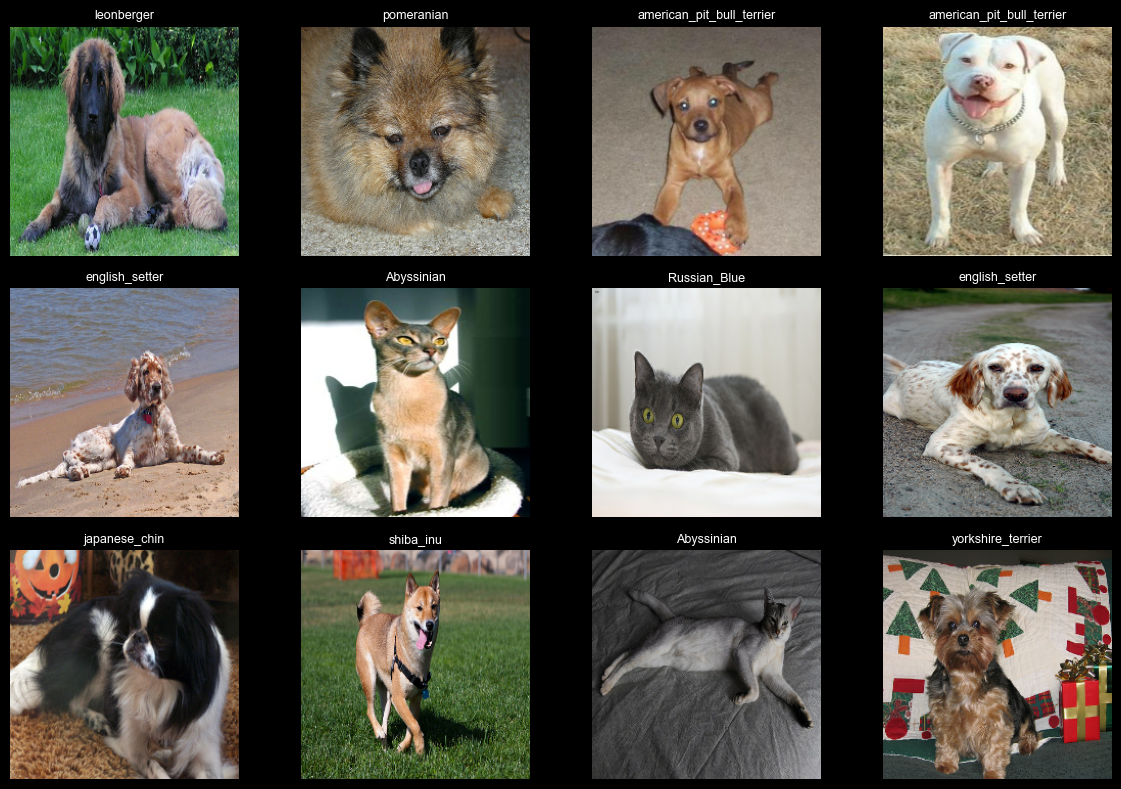

In [9]:
#
# Visualize Preprocessed Images
#

# Display a small grid of preprocessed training images.
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(12):

        # Plot each image in a 3 x 4 grid.
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i])

        # Convert label index to breed name for the title.
        label_index = int(labels[i].numpy())
        plt.title(breed_names[label_index], fontsize=9)

        plt.axis("off")

plt.tight_layout()
plt.show()

## 10. Build the Baseline CNN Model

The baseline model is a custom convolutional neural network trained from scratch.

This model is intentionally simpler than the transfer learning model we will build later. Its purpose is to provide a fair comparison point and to demonstrate the CNN concepts covered in class.

The baseline model uses:

- data augmentation,
- convolutional layers,
- batch normalization,
- max pooling,
- dropout,
- global average pooling,
- dense classification layer,
- softmax output over 37 breed classes.

In [10]:
#
# Build Baseline CNN Model
#

def build_baseline_cnn(input_shape=(224, 224, 3), num_classes=37):
    """
    Build a custom baseline CNN for pet breed classification.

    Parameters
    ----------
    input_shape : tuple
        Shape of the input images.

    num_classes : int
        Number of breed classes to predict.

    Returns
    -------
    keras.Model
        Compiled Keras CNN model.
    """

    # Define the input layer.
    inputs = keras.Input(shape=input_shape, name="input_image")

    # Apply data augmentation during training.
    # Keras augmentation layers automatically behave differently
    # during training and inference.
    x = data_augmentation(inputs)

    # First convolutional block.
    # This block learns low-level visual features such as edges and textures.
    x = layers.Conv2D(32, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    # Second convolutional block.
    # This block learns more complex local patterns.
    x = layers.Conv2D(64, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    # Third convolutional block.
    # This block increases the number of filters to capture richer features.
    x = layers.Conv2D(128, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    # Fourth convolutional block.
    # This deeper block helps the model learn higher-level image features.
    x = layers.Conv2D(256, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    # Global average pooling reduces each feature map to a single value.
    # This is more parameter-efficient than flattening the entire feature map.
    x = layers.GlobalAveragePooling2D()(x)

    # Dropout helps reduce overfitting.
    x = layers.Dropout(0.40)(x)

    # Dense layer before the final classifier.
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.30)(x)

    # Final softmax layer outputs one probability per breed class.
    outputs = layers.Dense(num_classes, activation="softmax", name="breed_probabilities")(x)

    # Build the model object.
    model = keras.Model(inputs=inputs, outputs=outputs, name="baseline_custom_cnn")

    return model


# Create the baseline CNN model.
baseline_model = build_baseline_cnn(
    input_shape=IMAGE_SIZE + (3,),
    num_classes=NUM_CLASSES
)

# Display model architecture.
baseline_model.summary()

Model: "baseline_custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ breed_probabilities (Dense)     │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 428,005 (1.63 MB)

 Trainable params: 427,045 (1.63 MB)

 Non-trainable params: 960 (3.75 KB)

## 11. Compile the Baseline CNN

The model uses sparse categorical cross-entropy because the labels are integer class labels rather than one-hot encoded vectors.

The optimizer is Adam with a modest learning rate. Accuracy is used as the primary metric for this baseline model.

In [11]:
#
# Compile Baseline CNN Model
#

# Compile the baseline CNN.
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 12. Define Training Callbacks

Callbacks help manage training and preserve the best model.

For this baseline CNN, we use:

- `EarlyStopping`: stops training when validation loss stops improving.
- `ModelCheckpoint`: saves the best model based on validation loss.
- `ReduceLROnPlateau`: reduces the learning rate if validation loss plateaus.

These callbacks make training more stable and reduce unnecessary epochs.

In [12]:
#
# Define Training Callbacks
#

# File path for the best baseline model.
baseline_model_path = MODEL_DIR / "baseline_cnn.keras"

# Stop training if validation loss does not improve for several epochs.
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Save the best model during training.
model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=baseline_model_path,
    monitor="val_loss",
    save_best_only=True
)

# Lower the learning rate if validation loss stops improving.
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

callbacks = [
    early_stopping,
    model_checkpoint,
    reduce_lr
]

## 13. Train the Baseline CNN

The baseline CNN is trained from scratch using the training set and monitored using the validation set.

Because this is a custom CNN without pretrained weights, we do not expect it to outperform the transfer learning model. The purpose is to establish a meaningful baseline.

In [13]:
#
# Train Baseline CNN Model
#

# Train the model.
baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 45s 474ms/step - accuracy: 0.0499 - loss: 3.7603 - val_accuracy: 0.0258 - val_loss: 3.8191 - learning_rate: 0.0010
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 45s 478ms/step - accuracy: 0.0584 - loss: 3.5921 - val_accuracy: 0.0217 - val_loss: 4.1737 - learning_rate: 0.0010
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 46s 488ms/step - accuracy: 0.0642 - loss: 3.5399 - val_accuracy: 0.0394 - val_loss: 4.1482 - learning_rate: 0.0010
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 45s 482ms/step - accuracy: 0.0853 - loss: 3.4426 - val_accuracy: 0.0435 - val_loss: 4.2097 - learning_rate: 5.0000e-04
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 45s 484ms/step - accuracy: 0.0863 - loss: 3.4106 - val_accuracy: 0.0408 - val_loss: 4.0222 - learning_rate: 5.0000e-04
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 45s 481ms/step - accuracy: 0.0941 - loss: 3.3500 - val_accuracy: 0.0543 - val_loss: 3.6253 - learning_rate: 2.5000e-04
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 45s 483ms/step - accuracy: 0.101

The baseline CNN trained for the full 20 epochs. Training accuracy improved gradually from about 5% to about 16%, while validation accuracy fluctuated and ended around 11%. This suggests that the custom CNN learned some signal but struggled to generalize well on the 37-class pet breed task. This result supports the need for transfer learning with a pretrained CNN.

## 14. Initial Baseline Training Observations

The baseline CNN trained for the full 20 epochs. Training accuracy gradually improved from approximately 5% to approximately 16%, while validation accuracy fluctuated and ended around 11%.

This result suggests that the custom CNN learned some visual signal from the training data, but the model struggled to generalize strongly across the 37 pet breed classes. This is not unexpected because the dataset contains natural images with variation in pose, lighting, scale, and background, and the baseline model was trained from scratch without pretrained visual features.

The relatively modest baseline performance provides a useful comparison point for the transfer learning model in the next notebook. We expect a pretrained CNN to perform substantially better because it begins with visual features learned from a much larger image dataset.

## 15. Save Training History

The Keras training history contains the loss, accuracy, validation loss, validation accuracy, and learning rate values recorded during training.

Saving this history allows us to reuse the results later in the final summary notebook, report, and presentation.

In [14]:
#
# Save Training History
#

# Convert the Keras History object into a pandas DataFrame.
baseline_history_df = pd.DataFrame(baseline_history.history)

# Add an epoch column using 1-based numbering for readability.
baseline_history_df.insert(0, "epoch", range(1, len(baseline_history_df) + 1))

# Save the training history to a CSV file.
baseline_history_path = RESULTS_DIR / "02_baseline_training_history.csv"

baseline_history_df.to_csv(baseline_history_path, index=False)

print(f"Saved baseline training history to: {baseline_history_path}")

# Display the first few rows.
baseline_history_df.head()

Saved baseline training history to: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/results/02_baseline_training_history.csv


,epoch,accuracy,loss,val_accuracy,val_loss,learning_rate
0,1,0.049932,3.760330,0.025815,3.819059,0.0010
1,2,0.058424,3.592118,0.021739,4.173701,0.0010
2,3,0.064198,3.539943,0.039402,4.148206,0.0010
3,4,0.085258,3.442575,0.043478,4.209694,0.0005
4,5,0.086277,3.410573,0.040761,4.022226,0.0005


## 16. Plot Training Curves

Training curves help us understand whether the model is learning, overfitting, underfitting, or plateauing.

For the baseline CNN, we plot:

1. training accuracy and validation accuracy,
2. training loss and validation loss.

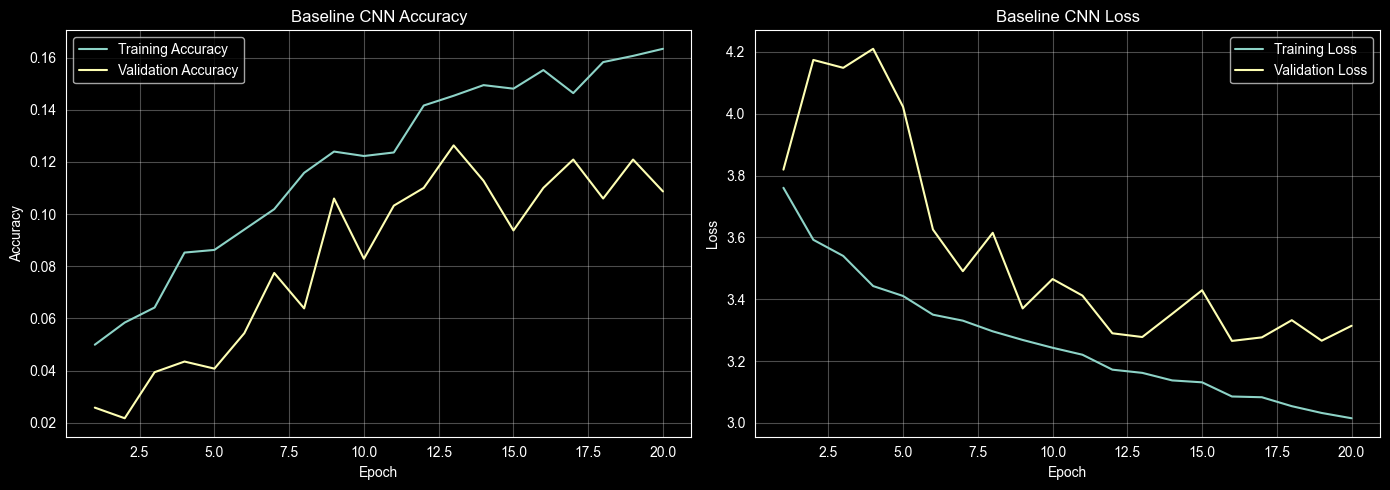

Saved baseline training curves to: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/figures/02_baseline_training_curves.png


In [15]:
#
# Plot Training Curves
#

# Create a figure with two side-by-side plots.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot training and validation accuracy.
axes[0].plot(baseline_history_df["epoch"], baseline_history_df["accuracy"], label="Training Accuracy")
axes[0].plot(baseline_history_df["epoch"], baseline_history_df["val_accuracy"], label="Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Baseline CNN Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot training and validation loss.
axes[1].plot(baseline_history_df["epoch"], baseline_history_df["loss"], label="Training Loss")
axes[1].plot(baseline_history_df["epoch"], baseline_history_df["val_loss"], label="Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Baseline CNN Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# Save the figure for later use in the report and presentation.
baseline_curves_path = FIGURE_DIR / "02_baseline_training_curves.png"
plt.savefig(baseline_curves_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved baseline training curves to: {baseline_curves_path}")

## 17. Evaluate the Baseline CNN on the Test Set

After training, we evaluate the baseline CNN on the official test set.

The test set was not used during training or validation, so it provides a better estimate of how the baseline model performs on unseen images.

In [16]:
#
# Evaluate Baseline CNN on Test Set
#

# Evaluate the trained baseline model on the official test dataset.
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(test_ds)

print(f"Baseline test loss: {baseline_test_loss:.4f}")
print(f"Baseline test accuracy: {baseline_test_accuracy:.4f}")

115/115 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - accuracy: 0.1117 - loss: 3.3162
Baseline test loss: 3.3162
Baseline test accuracy: 0.1117


## 18. Generate Test Predictions

To create a classification report and confusion matrix, we need predicted labels and true labels for every image in the test set.

In [17]:
#
# Generate Test Predictions
#

# Store true labels and predicted labels.
y_true = []
y_pred = []

# Loop through batches in the test dataset.
for image_batch, label_batch in test_ds:

    # Predict class probabilities for the current batch.
    batch_probabilities = baseline_model.predict(image_batch, verbose=0)

    # Convert probabilities to predicted class labels.
    batch_predictions = np.argmax(batch_probabilities, axis=1)

    # Store true and predicted labels.
    y_true.extend(label_batch.numpy())
    y_pred.extend(batch_predictions)

# Convert lists to NumPy arrays.
y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Number of true labels:", len(y_true))
print("Number of predicted labels:", len(y_pred))
print("First 10 true labels:", y_true[:10])
print("First 10 predicted labels:", y_pred[:10])

Number of true labels: 3669
Number of predicted labels: 3669
First 10 true labels: [19 20 28 28  4 18 22 36 18 16]
First 10 predicted labels: [14 33 14 14 18 18 22 32 10  3]


## 19. Classification Report

The classification report summarizes precision, recall, and F1-score for each breed class.

Because this is a 37-class problem and the baseline CNN is trained from scratch, we expect performance to be modest. The main purpose is to establish a comparison point for transfer learning.

In [18]:
#
# Create Classification Report
#

# Generate a classification report as a dictionary.
baseline_report = classification_report(
    y_true,
    y_pred,
    target_names=breed_names,
    output_dict=True,
    zero_division=0
)

# Convert the report to a DataFrame for display and saving.
baseline_report_df = pd.DataFrame(baseline_report).transpose()

# Save the classification report.
baseline_report_path = RESULTS_DIR / "02_baseline_classification_report.csv"

baseline_report_df.to_csv(baseline_report_path)

print(f"Saved baseline classification report to: {baseline_report_path}")

baseline_report_df.head(10)

Saved baseline classification report to: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/results/02_baseline_classification_report.csv


,precision,recall,f1-score,support
Abyssinian,0.225806,0.142857,0.175000,98.0
american_bulldog,0.150000,0.030000,0.050000,100.0
american_pit_bull_terrier,0.000000,0.000000,0.000000,100.0
basset_hound,0.059406,0.240000,0.095238,100.0
beagle,0.060606,0.040000,0.048193,100.0
Bengal,0.216216,0.080000,0.116788,100.0
Birman,0.098765,0.080000,0.088398,100.0
Bombay,0.285714,0.318182,0.301075,88.0
boxer,0.076923,0.040404,0.052980,99.0
British_Shorthair,0.125984,0.160000,0.140969,100.0


## 20. Confusion Matrix

The confusion matrix shows how often each true breed class was predicted as each possible breed class.

For 37 classes, the full matrix is dense, but it is still useful for identifying broad patterns and common confusions.

In [19]:
#
# Create Confusion Matrix Table
#

# Compute the confusion matrix.
baseline_cm = confusion_matrix(y_true, y_pred)

# Convert the confusion matrix to a labeled DataFrame.
baseline_cm_df = pd.DataFrame(
    baseline_cm,
    index=breed_names,
    columns=breed_names
)

# Save the confusion matrix table.
baseline_cm_path = RESULTS_DIR / "02_baseline_confusion_matrix.csv"

baseline_cm_df.to_csv(baseline_cm_path)

print(f"Saved baseline confusion matrix table to: {baseline_cm_path}")

baseline_cm_df.head()

Saved baseline confusion matrix table to: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/results/02_baseline_confusion_matrix.csv


,Abyssinian,american_bulldog,american_pit_bull_terrier,basset_hound,beagle,Bengal,Birman,Bombay,boxer,British_Shorthair,...,Russian_Blue,saint_bernard,samoyed,scottish_terrier,shiba_inu,Siamese,Sphynx,staffordshire_bull_terrier,wheaten_terrier,yorkshire_terrier
Abyssinian,14,0,0,12,1,2,4,3,1,5,...,1,2,2,2,0,2,6,2,3,1
american_bulldog,0,3,0,10,2,0,3,3,1,2,...,1,1,3,2,0,2,0,4,1,0
american_pit_bull_terrier,2,1,0,29,4,3,1,2,1,0,...,0,1,3,0,0,0,0,8,2,1
basset_hound,1,0,0,24,3,4,0,1,1,1,...,2,6,3,0,0,1,0,7,1,1
beagle,0,0,0,17,4,4,1,2,4,1,...,0,5,2,3,1,3,2,3,0,1


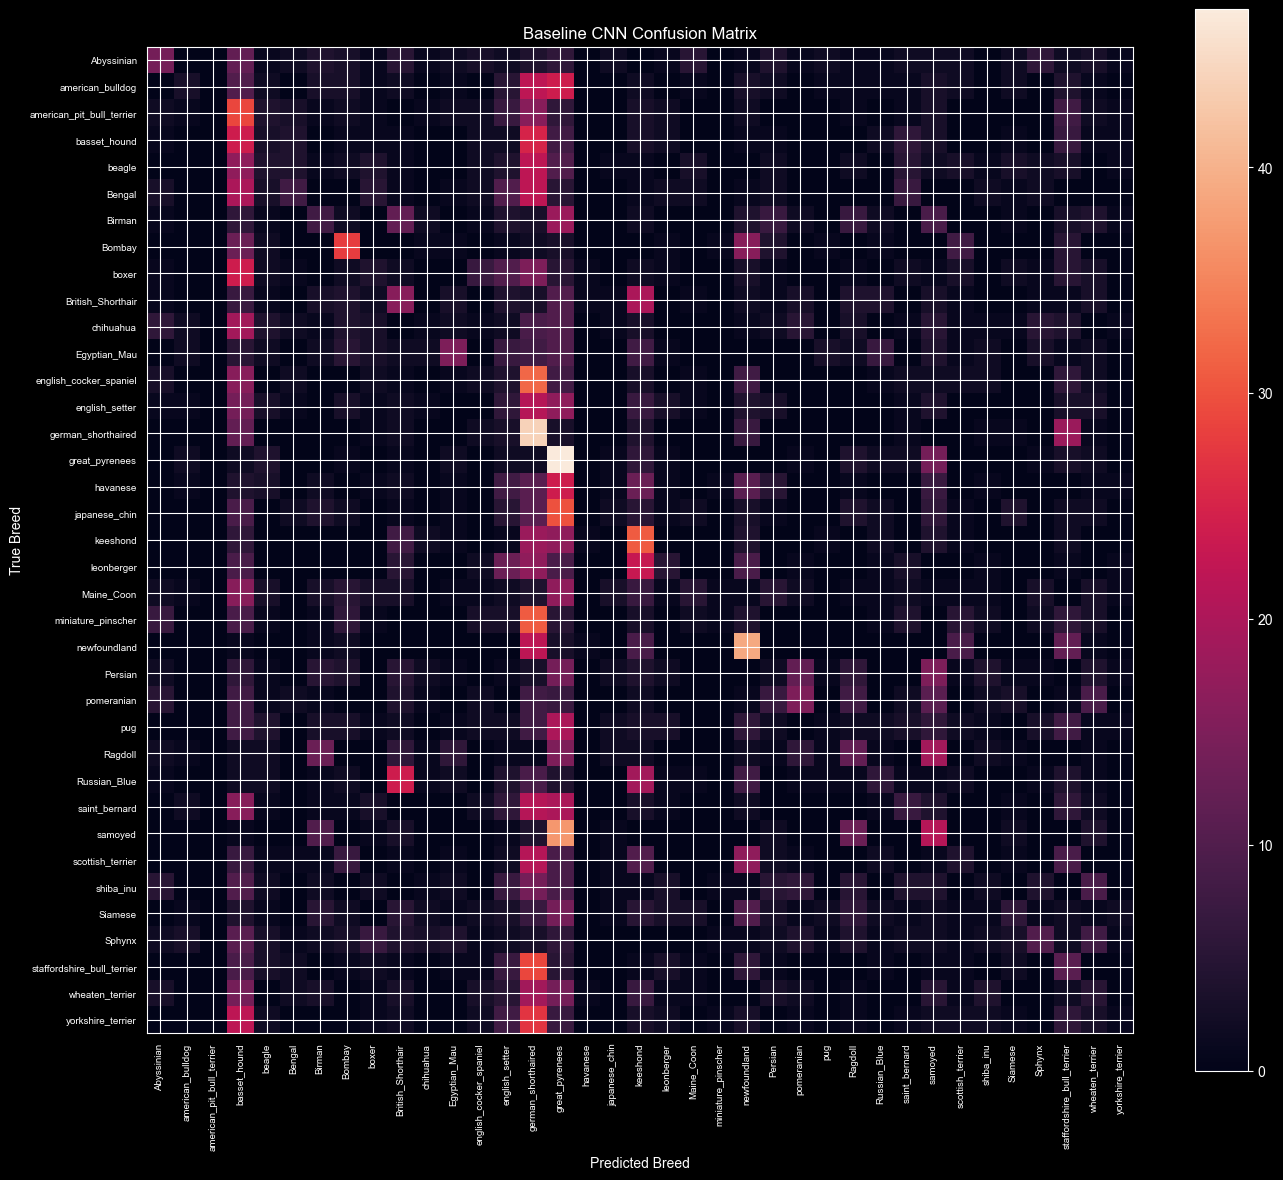

Saved baseline confusion matrix plot to: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/figures/02_baseline_confusion_matrix.png


In [20]:
#
# Plot Confusion Matrix
#

# Create a figure large enough to show all 37 class labels.
plt.figure(figsize=(14, 12))

plt.imshow(baseline_cm, interpolation="nearest")
plt.title("Baseline CNN Confusion Matrix")
plt.xlabel("Predicted Breed")
plt.ylabel("True Breed")

# Add class labels to both axes.
tick_marks = np.arange(len(breed_names))
plt.xticks(tick_marks, breed_names, rotation=90, fontsize=7)
plt.yticks(tick_marks, breed_names, fontsize=7)

# Add a colorbar to show count intensity.
plt.colorbar()

plt.tight_layout()

# Save the confusion matrix plot.
baseline_cm_fig_path = FIGURE_DIR / "02_baseline_confusion_matrix.png"
plt.savefig(baseline_cm_fig_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved baseline confusion matrix plot to: {baseline_cm_fig_path}")

## 21. Save Baseline Test Metrics

This section saves a compact summary of the baseline CNN's test performance. Later notebooks will use this table to compare the baseline CNN against transfer learning models.

In [21]:
#
# Save Baseline Test Metrics
#

# Create a compact model summary table.
baseline_metrics_df = pd.DataFrame([
    {
        "model_name": "baseline_custom_cnn",
        "model_type": "Custom CNN trained from scratch",
        "image_size": f"{IMAGE_SIZE[0]}x{IMAGE_SIZE[1]}",
        "num_classes": NUM_CLASSES,
        "epochs_run": len(baseline_history_df),
        "best_validation_accuracy": baseline_history_df["val_accuracy"].max(),
        "best_validation_loss": baseline_history_df["val_loss"].min(),
        "test_accuracy": baseline_test_accuracy,
        "test_loss": baseline_test_loss
    }
])

# Save the baseline metrics summary.
baseline_metrics_path = RESULTS_DIR / "02_baseline_metrics_summary.csv"

baseline_metrics_df.to_csv(baseline_metrics_path, index=False)

print(f"Saved baseline metrics summary to: {baseline_metrics_path}")

baseline_metrics_df

Saved baseline metrics summary to: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/results/02_baseline_metrics_summary.csv


,model_name,model_type,image_size,num_classes,epochs_run,best_validation_accuracy,best_validation_loss,test_accuracy,test_loss
0,baseline_custom_cnn,Custom CNN trained from scratch,224x224,37,20,0.126359,3.265255,0.111747,3.316179


## 22. Baseline CNN Interpretation

The baseline CNN trained for the full 20 epochs. Training accuracy improved gradually, while validation accuracy fluctuated and remained relatively low.

This suggests that the custom CNN learned some visual signal from the dataset but struggled to generalize strongly across the 37 pet breed classes. This result is not surprising because the Oxford-IIIT Pet Dataset contains natural images with substantial variation in pose, lighting, scale, and background.

The baseline model is still valuable because it establishes a comparison point. In the next modeling notebook, we will use transfer learning with a pretrained CNN. We expect the transfer learning model to perform substantially better because it begins with visual features learned from a much larger image dataset.

## 23. Notebook Summary

This notebook built and evaluated the first baseline classification model for the project.

Completed steps:

1. Loaded the Oxford-IIIT Pet Dataset.
2. Created training, validation, and test datasets.
3. Preprocessed images to `224 x 224` with pixel values scaled to `[0, 1]`.
4. Built a custom CNN using convolution, batch normalization, max pooling, dropout, and softmax classification.
5. Trained the model from scratch.
6. Saved the baseline model, training history, classification report, confusion matrix, and summary metrics.

The baseline CNN provides an initial performance benchmark. The next notebook will build a transfer learning model using a pretrained CNN architecture.